In [34]:
# The goal of this notebook is to 
# identify features that we can remove
# to simplify our modeling. 

# Our approach will be to:
#  (1) identify weak correlations
#    between features and
#    radon concentraiton target.
#    Those will represent features
#    that continue little information
#    and can be justified in their removal
#  (2) identify features that have high
#    correlation with other features.
#    These represent redundant features,
#    ie features which hold the 
#    same information as others. These
#    can also be eliminated



In [35]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif

# define project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

# Get file location stuff
from src.data.data_loading import load_full_dataset

In [36]:
FEATURE_KEEP = []
FEATURE_DROP = []
FEATURE_REVIEW = []

In [37]:
# load the _all_ the data to inspect data
#  (don't normally do this for cross validation!!!)
df = load_full_dataset()
df = df.copy()

# remove held-out test data
# df = df[~df["is_test"]].copy()

#print(df.head())

In [38]:

all_columns_list = df.columns.tolist()
print("\n-- ALL COLUMN NAMES FROM CV SPLIT --\n")
#print(zero_valued_columns_to_drop)
for i, col in enumerate(sorted(all_columns_list), 1):
    print(f"\"{col}\",")
    #print(f"{i:2d}  {col}")


-- ALL COLUMN NAMES FROM CV SPLIT --

"FSA",
"average_heating_days",
"concentration",
"cv_fold",
"demogr_avg_household_size",
"demogr_frac_tenure_band",
"demogr_frac_tenure_owned",
"demogr_frac_tenure_rented",
"demogr_median_age",
"demogr_num_occ_dwellings",
"demogr_num_total_dwellings",
"demogr_pop_2016",
"geolprov_appalachian_orogen",
"geolprov_arctic_continental_shelf",
"geolprov_arctic_platform",
"geolprov_atlantic_continental_shelf",
"geolprov_bear_province",
"geolprov_churchill_province",
"geolprov_cordilleran_orogen",
"geolprov_grenville_province",
"geolprov_hudson_bay_lowlands",
"geolprov_innuitian_orogen",
"geolprov_interior_platform",
"geolprov_nain_province",
"geolprov_oceanic_crust",
"geolprov_pacific_continental_shelf",
"geolprov_slave_province",
"geolprov_southern_province",
"geolprov_st_lawrence_platform",
"geolprov_superior_province",
"geolprov_unknown",
"geometry",
"hous_avg_rooms",
"hous_frac_age_1981_2000",
"hous_frac_age_post_2001",
"hous_frac_age_pre_1980",
"hous_

In [39]:
# Add log of Radon concentraiton
#   (radon concentraiton is approx. log-normal distributed)

df["log_concentration"] = np.log(df["concentration"])


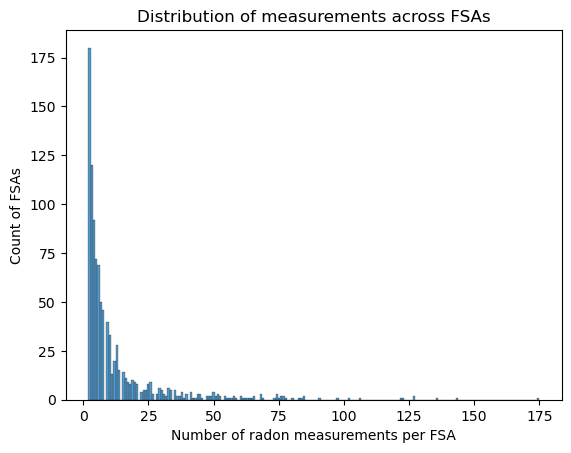

2


In [40]:
homes_per_fsa = df.groupby("FSA").size()


import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(homes_per_fsa, bins=200)

plt.xlabel("Number of radon measurements per FSA")
plt.ylabel("Count of FSAs")
plt.title("Distribution of measurements across FSAs")

plt.show()

print(min(homes_per_fsa))

Note that the following approach is wrong... at least for how Mani is envisioning oour target. Instead, the target should be radon > 200.  then, e.g. in logistic regression, we will say that if the likelihood that a house has a radon concentration greater than 200 w/in an FSA is the same as the fraction of houses in an FSA that have radon >200.  i'm not really sure how that is true? but that is what we are doing.  i am also not sure how that applies to other models.  

In [41]:
# Build the Exceedance statistics per FSA 
#  Represents some baseline 'truth' for each FSA against which we can evaluate our results...

RADON_CONC_HEALTH_RISK = 200

df["radon_danger_conc"] = (df["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)


# Compute the fraction of houses exceeding the threshold within each FSA 
fsa_stats = (
    df.groupby("FSA")
      .agg(
          n_measurements=("concentration", "size"),
          mean_radon=("concentration", "mean"),
          mean_log_radon=("log_concentration", "mean"),
          frac_danger=("radon_danger_conc", "mean")
      )
      .reset_index()
)


# Make some baseline classification target measure

RISK_THRESHOLD = 0.10

fsa_stats["high_risk_fsa"] = (fsa_stats["frac_danger"] >= RISK_THRESHOLD).astype(int)


## MANI says that we should predict on whether each measuremnt is greater or less than 200, not  

In [42]:
fsa_stats.head()

,FSA,n_measurements,mean_radon,mean_log_radon,frac_danger,high_risk_fsa
0,A0A,13,69.230769,3.505548,0.076923,0
1,A0B,3,48.833333,3.217379,0.000000,0
2,A0C,5,53.900000,3.564603,0.000000,0
3,A0E,17,31.588235,2.985624,0.000000,0
4,A0G,65,70.769231,3.291055,0.030769,0


In [43]:
# At threshold = 0.10, the data is actually not super imbalanced!
# However, i don't think this matters for how we are doing things (target is 'radon of house w/in FSA > 200', it is NOT '>10% chance a house has radon > 200')

fsa_stats["high_risk_fsa"].value_counts(normalize=True)

high_risk_fsa
0    0.706468
1    0.293532
Name: proportion, dtype: float64

In [44]:
zero_columns = df.columns[(df == 0).all()]

print(zero_columns.tolist())

['geolprov_arctic_continental_shelf', 'geolprov_arctic_platform', 'geolprov_bear_province', 'geolprov_innuitian_orogen', 'geolprov_slave_province', 'geolprov_oceanic_crust', 'sedi_weathered_bedrock_or_regolith']


In [45]:
#  Now, we can *almost* look at some stuff!
#   We just need to do a little more 
#   data handling...  
#     - Eliminate non-feature columns in the data
#     - Impute NaN (this is justforr the uranium conc. data)


# IDENTIFY & DROP NON-FEATURE COLUMNS

# Define the feature data

X = df.copy()

# Specify non-feature data
#  in the df columns... 
#  (1) Radon data and metadata
#   see: jb_eda_validFeatures.ipynb for more information
basal_non_feature_columns = [
    "FSA",
    "n_days",
    "concentration",
    "provinceterritory",
    "geometry",
    "spatial_cluster",
    "is_test",
    "cv_fold",
]

# (2) Additional radon data we just made today...
local_non_feature_columns = [
    "log_concentration", 
    "radon_danger_conc",
]

#  Both of these form columns that represent non-features
non_feature_columns = basal_non_feature_columns + local_non_feature_columns


#  There are other columns that we should immediately drop from the data, too

# (3) Some columns are parts of groups 
#   that add to 1 and therefore 
#   are not independent variables.
#   I call these compositional featuers
#   and i record one of them to be removed
compositional_columns_to_drop = [
    "hous_frac_type_movable",
    "hous_frac_age_1981_2000",
    "demogr_frac_tenure_rented",
]

# (4) Some of the features are zero for every datapoint. 
#   These have no information content and should be dropped.

zero_valued_columns_to_drop = df.columns[(df == 0).all()].tolist()
print("-- COLUMNS WITH ONLY ZEROS --")
#print(zero_valued_columns_to_drop)
for i, col in enumerate(sorted(zero_valued_columns_to_drop), 1):
    print(f"{i:2d}  {col}")

non_informative_feature_columns = list(dict.fromkeys(compositional_columns_to_drop + zero_valued_columns_to_drop))

# 
# (5) We build a list of all these together that should be dropped.
initial_columns_to_drop = list(dict.fromkeys(non_feature_columns + non_informative_feature_columns))

# Now that we have made our list
#  of non-features, we cut 'em out
X = X.drop(columns=initial_columns_to_drop)
print("\n-- REMAINING FEATURES --")
for i, col in enumerate(sorted(X.columns), 1):
    print(f"{i:2d}  {col}")


# record dropped columns for posterity 
print("\n-- DROPPED COLUMNS --")
FEATURE_DROP = list(dict.fromkeys(FEATURE_DROP + initial_columns_to_drop))
for i, col in enumerate(sorted(FEATURE_DROP), 1):
    print(f"{i:2d}  {col}")

# Define the target data

y = df["radon_danger_conc"]



-- COLUMNS WITH ONLY ZEROS --
 1  geolprov_arctic_continental_shelf
 2  geolprov_arctic_platform
 3  geolprov_bear_province
 4  geolprov_innuitian_orogen
 5  geolprov_oceanic_crust
 6  geolprov_slave_province
 7  sedi_weathered_bedrock_or_regolith

-- REMAINING FEATURES --
 1  average_heating_days
 2  demogr_avg_household_size
 3  demogr_frac_tenure_band
 4  demogr_frac_tenure_owned
 5  demogr_median_age
 6  demogr_num_occ_dwellings
 7  demogr_num_total_dwellings
 8  demogr_pop_2016
 9  geolprov_appalachian_orogen
10  geolprov_atlantic_continental_shelf
11  geolprov_churchill_province
12  geolprov_cordilleran_orogen
13  geolprov_grenville_province
14  geolprov_hudson_bay_lowlands
15  geolprov_interior_platform
16  geolprov_nain_province
17  geolprov_pacific_continental_shelf
18  geolprov_southern_province
19  geolprov_st_lawrence_platform
20  geolprov_superior_province
21  geolprov_unknown
22  hous_avg_rooms
23  hous_frac_age_post_2001
24  hous_frac_age_pre_1980
25  hous_frac_major_rep

In [ ]:
# For missing data, impute with median. 
#  this is basically only for Uranium data...
#  it might be better to just leave this column out???

nan_counts = X.isna().sum().sort_values(ascending=False)
nan_counts[nan_counts > 0].head(20)
X = X.fillna(X.median())

In [ ]:
# Look at the variance of the data. 
#   Features with very low variance could be eliminated

from sklearn.feature_selection import VarianceThreshold

# Inspect variance before filtering
feature_variance = X.var().sort_values()

print("Lowest variance features:")
print(feature_variance.head(25))
print("Highest variance features:")
print(feature_variance.tail(5))



import matplotlib.pyplot as plt

feature_variance_trimmed = feature_variance.drop(
    feature_variance.nlargest(20).index
)
feature_variance_trimmed.plot(kind="hist", bins=100)
plt.title("Distribution of Feature Variance")
plt.xlabel("Variance")
plt.ylabel("Number of Features")
plt.show()




In [ ]:

# # Apply variance threshold
# variance_threshold = 0.01

# selector = VarianceThreshold(threshold=variance_threshold)

# X_var = selector.fit_transform(X)

# # Get remaining feature names
# selected_features = X.columns[selector.get_support()]

# # Convert back to dataframe for easier inspection
# X = pd.DataFrame(X_var, columns=selected_features, index=X.index)

# print("\nNumber of features before filtering:", len(feature_variance))
# print("Number of features after filtering:", len(selected_features))

# removed_features = feature_variance.index.difference(selected_features)

# print("\nRemoved low-variance features:")
# print(list(removed_features))

In [ ]:
# Create a threshold for low vairnac efeatures and drop those...

LOW_VARIANCE_THRESHOLD = 0.0001

low_variance_features = feature_variance[
    feature_variance < LOW_VARIANCE_THRESHOLD
].index.tolist()

print(low_variance_features)

FEATURE_DROP += low_variance_features

In [ ]:
# START EVALUATING FEATURE REDUNDANCY
# check out magnitude of the correlations between features

corr = X.corr().abs()

# ignore duplicate Corr's
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# find weirdly big ones
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(len(to_drop), "features to drop")
print(to_drop)

In [ ]:
print(upper)

In [ ]:
# Inspect correlated pairs
 
high_corr = (
    corr.stack()
        .reset_index()
)

high_corr.columns = ["feature1","feature2","corr"]

high_corr = high_corr[
    (high_corr["feature1"] != high_corr["feature2"]) &
    (high_corr["corr"] > 0.8)
]

high_corr.sort_values("corr", ascending=False).head(20)

In [ ]:
# drop redundant variables
X = X.drop(columns=to_drop)
FEATURE_DROP += to_drop

In [ ]:
# Do mutual information classification to see what is the most important variable w/r/t our 'target'

mi = mutual_info_classif(X, y, random_state=0)

mi_scores = (
    pd.Series(mi, index=X.columns)
      .sort_values(ascending=False)
)

print("-- TOP 40 Mutual Information Scores --")
print(mi_scores.head(40))

print("-- BOTTOM 25 Mutual Information Scores --")
print(mi_scores.tail(20))

In [ ]:
LOW_MI_THRESHOLD = 0.002

low_mi_features = mi_scores[
    mi_scores < LOW_MI_THRESHOLD
].index.tolist()

FEATURE_DROP += low_mi_features

In [ ]:
plt.figure(figsize=(6,4))

mi_scores.plot(
    kind="hist",
    bins=30
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Number of Features")
plt.title("Distribution of Mutual Information Scores")

plt.show()

In [ ]:
# Looking at the ranking curve of the MI scores
#   shows clear places where cutoffs could be made
#   Cut at 20: clear discontinuous drop
#   Cut at 25: ~ 50% MI drop
#   Cut at 40: another discontinous change
#   Cut at 60: values reach 0

plt.figure(figsize=(6,4))

mi_scores.reset_index(drop=True).plot()

plt.ylabel("Mutual Information")
plt.xlabel("Feature Rank")
plt.title("Mutual Information Ranked Curve")

plt.show()

In [ ]:
HIGH_MI_THRESHOLD = 0.01

high_mi_features = mi_scores[
    mi_scores > HIGH_MI_THRESHOLD
].index.tolist()

FEATURE_KEEP += high_mi_features

print(FEATURE_KEEP)

In [ ]:
len(FEATURE_DROP)

In [ ]:
# Try to do some basic logistic regresssion


from src.data.data_loading import (
    load_training_data,
    load_validation_data
)

# Load the training and validation data
train = load_training_data(cv_fold=0)
val = load_validation_data(cv_fold=0)

# Remove everything but the good features
# Add uranium to dropped data (or impute...)
FEATURE_DROP += ["max_uranium", "mean_uranium"]
FEATURE_DROP_train = [c for c in FEATURE_DROP if c in train.columns]
FEATURE_DROP_val = [c for c in FEATURE_DROP if c in val.columns]
X_train = train.drop(columns=FEATURE_DROP_train)
X_val = val.drop(columns=FEATURE_DROP_val)


# Define the targets
train["radon_danger_conc"] = (train["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)
val["radon_danger_conc"] = (val["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)

y_train = train["radon_danger_conc"]
y_val = val["radon_danger_conc"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

In [ ]:
model.score(X_val_scaled, y_val)

In [ ]:
from sklearn.metrics import classification_report

pred = model.predict(X_val_scaled)

print(classification_report(y_val, pred))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

In [ ]:
probs = model.predict_proba(X_val_scaled)[:,1]

In [ ]:
import matplotlib.pyplot as plt

plt.hist(probs, bins=50)
plt.title("Predicted probability of high radon")

In [ ]:
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

pred = model.predict(X_val_scaled)

print(classification_report(y_val, pred))

In [ ]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_val_scaled)[:,1]
roc_auc_score(y_val, probs)

In [ ]:
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

pred = model.predict(X_val_scaled)

print(classification_report(y_val, pred))

In [ ]:
probs = model.predict_proba(X_val_scaled)[:,1]
roc_auc_score(y_val, probs)

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_val, probs)

In [ ]:
model.coef_

In [ ]:
import pandas as pd

coefficients = pd.Series(
    model.coef_[0],
    index=X_train.columns
)

In [ ]:
coefficients_sorted = coefficients.sort_values(key=abs, ascending=False)

print(coefficients_sorted.head(20))

In [ ]:
import matplotlib.pyplot as plt

coefficients_sorted.head(20).plot.barh(figsize=(8,6))
plt.title("Top Logistic Regression Feature Coefficients")
plt.show()

In [ ]:
weak_features = coefficients[coefficients.abs() < 0.01]

print(len(weak_features))
print(weak_features.index.tolist())

In [ ]:
coefficients = pd.Series(model.coef_[0], index=X_train.columns)

coef_table = (
    coefficients
    .sort_values(key=abs, ascending=False)
    .to_frame("coefficient")
)

print(coef_table.head(25))

In [ ]:
probs = model.predict_proba(X_val_scaled)[:,1]
import pandas as pd
import matplotlib.pyplot as plt

df_eval = pd.DataFrame({
    "pred_prob": probs,
    "truth": y_val
})

# Create 10 bins of predicted probability
df_eval["risk_bin"] = pd.qcut(df_eval["pred_prob"], 10, duplicates="drop")

# Compute observed rate in each bin
bin_summary = df_eval.groupby("risk_bin")["truth"].mean()

plt.figure(figsize=(6,4))
bin_summary.plot(marker="o")
plt.ylabel("Observed high-radon rate")
plt.xlabel("Predicted risk bin (low → high)")
plt.title("Model calibration / risk ranking")
plt.show()

In [ ]:
plt.hist(probs[y_val==0], bins=40, alpha=0.5, label="low radon")
plt.hist(probs[y_val==1], bins=40, alpha=0.5, label="high radon")

plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability separation")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(
    val["longitude"],
    val["latitude"],
    c=y_val,
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="High radon (>200)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Observed high-radon FSAs")
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(
    val["longitude"],
    val["latitude"],
    c=probs,
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Predicted risk")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predicted radon risk")
plt.show()

In [ ]:
cluster_rates = train.groupby("spatial_cluster")["radon_danger_conc"].mean()

cluster_rates.sort_values().head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    val["demogr_pop_2016"],
    y_val,
    alpha=0.3
)

plt.xscale("log")

plt.xlabel("Population (log scale)")
plt.ylabel("High radon indicator")
plt.title("High radon vs population")
plt.show()

In [ ]:
import pandas as pd

df_eval = val.copy()
df_eval["high_radon"] = y_val

df_eval["pop_bin"] = pd.qcut(df_eval["demogr_pop_2016"], 10)

pop_summary = df_eval.groupby("pop_bin")["high_radon"].mean()

pop_summary.plot(marker="o")
plt.ylabel("Observed high-radon rate")
plt.xlabel("Population bin (low → high)")
plt.title("Radon risk vs FSA population")
plt.show()

In [ ]:
plt.scatter(
    val["demogr_pop_2016"],
    probs,
    alpha=0.4
)

plt.xscale("log")

plt.xlabel("Population")
plt.ylabel("Predicted radon probability")
plt.title("Predicted radon risk vs population")
plt.show()

In [ ]:
X_no_pop = X.drop(columns=[
    "demogr_pop_2016",
    "demogr_num_total_dwellings",
    "demogr_num_occ_dwellings"
], errors="ignore")

mi = mutual_info_classif(X_no_pop, y_train)

pd.Series(mi, index=X_no_pop.columns).sort_values(ascending=False).head(20)